# Task 3: Energy Consumption Time Series Forecasting

## Objective

The objective of this project is to forecast short-term household energy consumption using historical time-series patterns.

The project compares multiple forecasting approaches including:
- ARIMA
- Prophet
- XGBoost

The models are evaluated using:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('../images', exist_ok=True)

Importing plotly failed. Interactive plots will not work.


In [2]:
df = pd.read_csv(
    '../data/household_power_consumption.txt',
    sep=';',
    low_memory=False,
    na_values='?',
    parse_dates={'Datetime': ['Date', 'Time']},
    infer_datetime_format=True,
    nrows=50000
)

df.head()

,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## Dataset Overview

The dataset contains household electric power consumption measurements collected over time. In this notebook, the first 50,000 rows are loaded from `../data/household_power_consumption.txt`.

Important features include:
- Global active power, used as the forecasting target
- Voltage
- Global intensity
- Sub metering values

In [3]:
print("Shape:", df.shape)

df.info()

Shape: (50000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Datetime               50000 non-null  datetime64[ns]
 1   Global_active_power    49995 non-null  float64       
 2   Global_reactive_power  49995 non-null  float64       
 3   Voltage                49995 non-null  float64       
 4   Global_intensity       49995 non-null  float64       
 5   Sub_metering_1         49995 non-null  float64       
 6   Sub_metering_2         49995 non-null  float64       
 7   Sub_metering_3         49995 non-null  float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 3.1 MB


In [4]:
df.isnull().sum()

Datetime                 0
Global_active_power      5
Global_reactive_power    5
Voltage                  5
Global_intensity         5
Sub_metering_1           5
Sub_metering_2           5
Sub_metering_3           5
dtype: int64

In [5]:
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'],
    errors='coerce'
)

df.dropna(inplace=True)

df.head()

,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## Time Series Preprocessing

The datetime column was parsed and set as the index for time series analysis.

In [6]:
df.set_index('Datetime', inplace=True)

df.sort_index(inplace=True)

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [7]:
hourly_data = df['Global_active_power'].resample('H').mean()

hourly_data.head()

Datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
Freq: h, Name: Global_active_power, dtype: float64

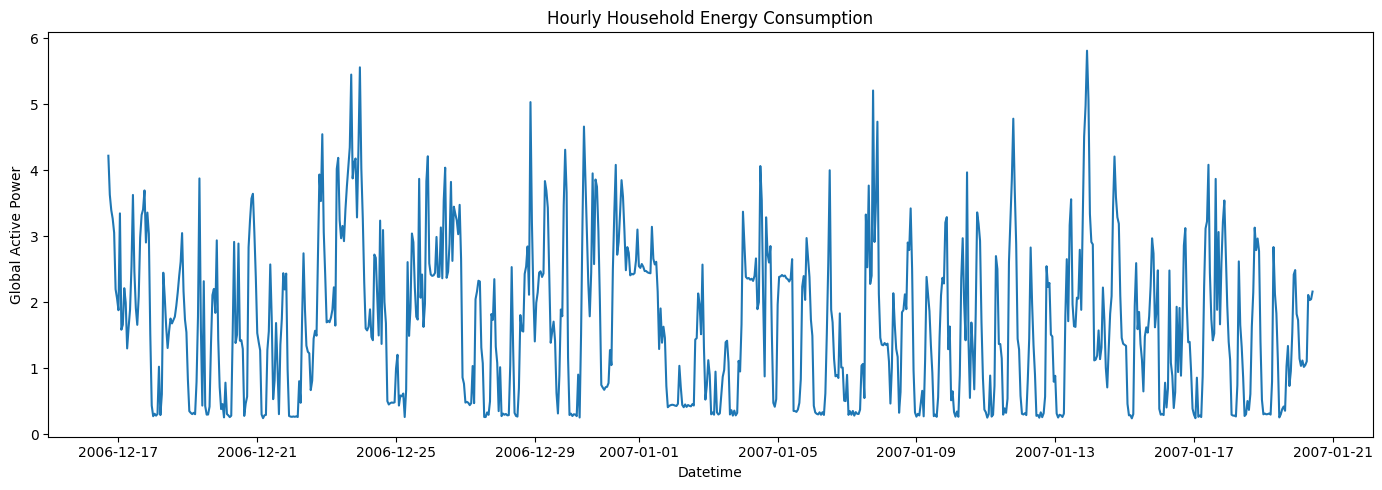

In [8]:
plt.figure(figsize=(14,5))

plt.plot(hourly_data)

plt.title('Hourly Household Energy Consumption')

plt.xlabel('Datetime')
plt.ylabel('Global Active Power')

plt.tight_layout()

plt.savefig('../images/hourly_energy_consumption.png')

plt.show()

## Feature Engineering

Time-based features were created to help machine learning models capture temporal patterns. The engineered features include hour, day, month, weekday, and weekend indicators.

In [9]:
ts_df = hourly_data.reset_index()

ts_df.columns = ['Datetime', 'Power']

ts_df['Hour'] = ts_df['Datetime'].dt.hour
ts_df['Day'] = ts_df['Datetime'].dt.day
ts_df['Month'] = ts_df['Datetime'].dt.month
ts_df['Weekday'] = ts_df['Datetime'].dt.weekday

ts_df['Weekend'] = ts_df['Weekday'].apply(
    lambda x: 1 if x >= 5 else 0
)

ts_df.head()

,Datetime,Power,Hour,Day,Month,Weekday,Weekend
0,2006-12-16 17:00:00,4.222889,17,16,12,5,1
1,2006-12-16 18:00:00,3.632200,18,16,12,5,1
2,2006-12-16 19:00:00,3.400233,19,16,12,5,1
3,2006-12-16 20:00:00,3.268567,20,16,12,5,1
4,2006-12-16 21:00:00,3.056467,21,16,12,5,1


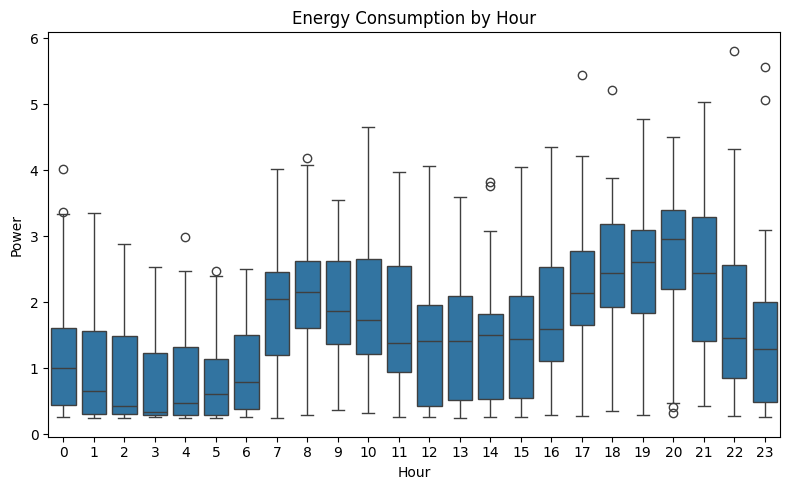

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Hour', y='Power', data=ts_df)

plt.title('Energy Consumption by Hour')

plt.tight_layout()

plt.savefig('../images/hourly_consumption_pattern.png')

plt.show()

## Train-Test Split

The hourly data is split chronologically, with 80% used for training and 20% used for testing.

In [11]:
train_size = int(len(ts_df) * 0.8)

train = ts_df[:train_size]
test = ts_df[train_size:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (667, 7)
Test shape: (167, 7)


# ARIMA Forecasting

In [12]:
arima_model = ARIMA(train['Power'], order=(2,1,2))

arima_result = arima_model.fit()

arima_forecast = arima_result.forecast(steps=len(test))

In [13]:
arima_mae = mean_absolute_error(test['Power'], arima_forecast)

arima_rmse = np.sqrt(
    mean_squared_error(test['Power'], arima_forecast)
)

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

ARIMA MAE: 0.8925846114085567
ARIMA RMSE: 1.1127388657684179


# Prophet Forecasting

In [14]:
prophet_train = train[['Datetime', 'Power']]

prophet_train.columns = ['ds', 'y']

prophet_model = Prophet()

prophet_model.fit(prophet_train)

08:34:33 - cmdstanpy - INFO - Chain [1] start processing
08:34:35 - cmdstanpy - INFO - Chain [1] done processing


In [15]:
future = prophet_model.make_future_dataframe(
    periods=len(test),
    freq='H'
)

forecast = prophet_model.predict(future)

prophet_forecast = forecast['yhat'].tail(len(test)).values

In [16]:
prophet_mae = mean_absolute_error(
    test['Power'],
    prophet_forecast
)

prophet_rmse = np.sqrt(
    mean_squared_error(test['Power'], prophet_forecast)
)

print("Prophet MAE:", prophet_mae)
print("Prophet RMSE:", prophet_rmse)

Prophet MAE: 0.6661551277661695
Prophet RMSE: 0.9402814803867731


# XGBoost Forecasting

In [17]:
features = ['Hour', 'Day', 'Month', 'Weekday', 'Weekend']

X_train = train[features]
y_train = train['Power']

X_test = test[features]
y_test = test['Power']

In [18]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_forecast = xgb_model.predict(X_test)

In [19]:
xgb_mae = mean_absolute_error(y_test, xgb_forecast)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_forecast)
)

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)

XGBoost MAE: 0.6088146255586862
XGBoost RMSE: 0.8336349926129908


## Model Comparison

In [20]:
results = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost'],
    'MAE': [arima_mae, prophet_mae, xgb_mae],
    'RMSE': [arima_rmse, prophet_rmse, xgb_rmse]
})

results

,Model,MAE,RMSE
0,ARIMA,0.892585,1.112739
1,Prophet,0.666155,0.940281
2,XGBoost,0.608815,0.833635


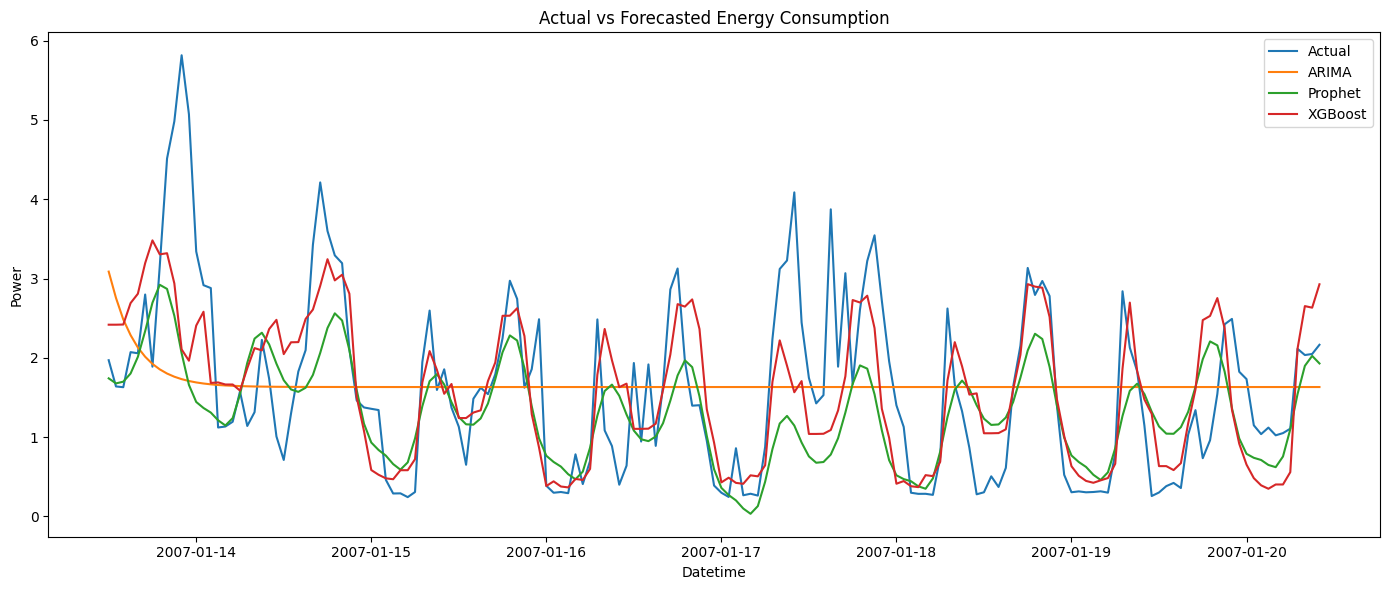

In [21]:
plt.figure(figsize=(14,6))

plt.plot(test['Datetime'], test['Power'], label='Actual')

plt.plot(test['Datetime'], arima_forecast, label='ARIMA')

plt.plot(test['Datetime'], prophet_forecast, label='Prophet')

plt.plot(test['Datetime'], xgb_forecast, label='XGBoost')

plt.legend()

plt.title('Actual vs Forecasted Energy Consumption')

plt.xlabel('Datetime')
plt.ylabel('Power')

plt.tight_layout()

plt.savefig('../images/model_forecasts.png')

plt.show()

## Final Conclusion

This project forecasted short-term household energy consumption using three different forecasting techniques:
- ARIMA
- Prophet
- XGBoost

Time-based features such as hour, day, month, weekday, and weekend indicators were engineered to improve prediction quality.

The models were evaluated using MAE and RMSE, and forecast visualizations were generated to compare actual and predicted values.

The project demonstrates the importance of temporal feature engineering and model comparison in time series forecasting problems.